In [65]:
# We start by importing all the necessary packages
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math

In [66]:
# We now set all the parameters that we need

# Parameters
N = 40          # Grid points (also L96 dimension)
dx = 1       # Spatial step
alpha = 0.5
beta = 0.6
F_L96 = 4.0     # L96 forcing

In [67]:
def advection_upwind(C, u, dx):
    """Upwind advection: -u * dC/dx with periodic BCs."""
    dCdx = torch.where(
        u >= 0,
        (C - torch.roll(C, 1)) / dx,   # Backward diff for u > 0
        (torch.roll(C, -1) - C) / dx   # Forward diff for u < 0
    )
    return -u * dCdx

In [111]:
def rk4_advection(C, dt):
    u_const = torch.full((N,), 2.0)
    k1 = advection_upwind(C, u_const, dx)
    k2 = advection_upwind(C + 0.5 * dt * k1, u_const, dx)
    k3 = advection_upwind(C + 0.5 * dt * k2, u_const,dx)
    k4 = advection_upwind(C + dt * k3, u_const, dx)
    
    return C + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

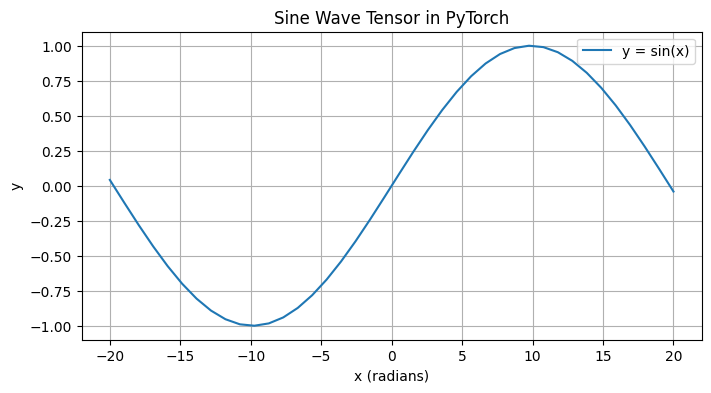

tensor([-20.0000, -18.9744, -17.9487, -16.9231, -15.8974, -14.8718, -13.8462,
        -12.8205, -11.7949, -10.7692,  -9.7436,  -8.7179,  -7.6923,  -6.6667,
         -5.6410,  -4.6154,  -3.5897,  -2.5641,  -1.5385,  -0.5128,   0.5128,
          1.5385,   2.5641,   3.5897,   4.6154,   5.6410,   6.6667,   7.6923,
          8.7179,   9.7436,  10.7692,  11.7949,  12.8205,  13.8462,  14.8718,
         15.8974,  16.9231,  17.9487,  18.9744,  20.0000])


In [115]:
# We generate a sine curve to test the advection scheme
start_angle = -20
end_angle = 20
dt = 0.1
N = 40
# Create the input tensor of angles (x-values)
x = torch.linspace(start_angle, end_angle, N)
y = torch.sin(0.5*x/math.pi)
C = y
y_base = y
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y.numpy(), label='y = sin(x)')
plt.title('Sine Wave Tensor in PyTorch')
plt.xlabel('x (radians)')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()
print(x)


In [116]:
steps = 200


# Reset C
C = y_base

for _ in tqdm(range(steps)):
    # trajectory.append(C.clone())  # store current state
    # times.append(t)
    
    C = rk4_advection(C, dt)

100%|██████████| 200/200 [00:00<00:00, 7450.38it/s]


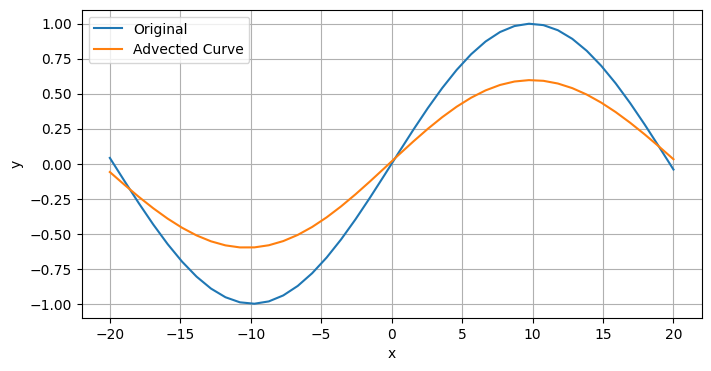

In [117]:
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y_base.numpy(), label='Original')
plt.plot(x.numpy(),C.numpy(), label='Advected Curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()

In [108]:
# We will now compute the L2 error of the curve
def L_2_error(N, x, x_ref):
    error = 0
    norm = 0
    for i in range(N):
        er = (x[i] - x_ref[i])**2
        # print()
        error += er
        # print(x[i], x_ref[i])
        # print(i)
    for i in range(N):

        norm +=   (x_ref[i])**2
    L2 = torch.sqrt(error/norm)
    
    
    return L2

In [109]:
error = L_2_error(N, C, y_base)
print(error)


tensor(0.3947)


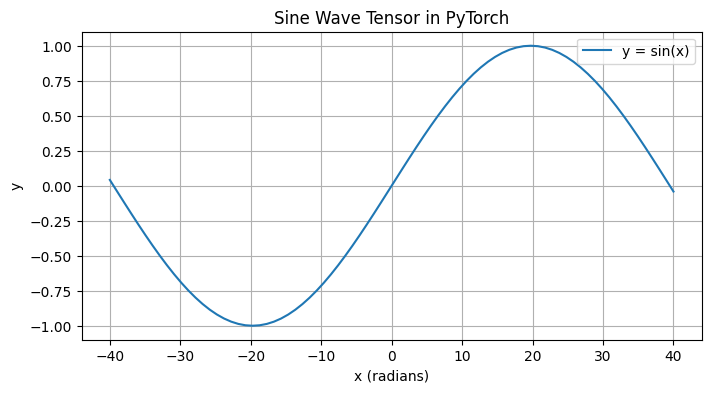

tensor([-40.0000, -38.9873, -37.9747, -36.9620, -35.9494, -34.9367, -33.9240,
        -32.9114, -31.8987, -30.8861, -29.8734, -28.8608, -27.8481, -26.8354,
        -25.8228, -24.8101, -23.7975, -22.7848, -21.7722, -20.7595, -19.7468,
        -18.7342, -17.7215, -16.7089, -15.6962, -14.6835, -13.6709, -12.6582,
        -11.6456, -10.6329,  -9.6203,  -8.6076,  -7.5949,  -6.5823,  -5.5696,
         -4.5570,  -3.5443,  -2.5316,  -1.5190,  -0.5063,   0.5063,   1.5190,
          2.5316,   3.5443,   4.5570,   5.5696,   6.5823,   7.5949,   8.6076,
          9.6203,  10.6329,  11.6456,  12.6582,  13.6709,  14.6835,  15.6962,
         16.7089,  17.7215,  18.7342,  19.7468,  20.7595,  21.7722,  22.7848,
         23.7975,  24.8101,  25.8228,  26.8354,  27.8481,  28.8608,  29.8734,
         30.8861,  31.8987,  32.9114,  33.9240,  34.9367,  35.9494,  36.9620,
         37.9747,  38.9873,  40.0000])


In [148]:
# We will now double the resolution in both space and time
dt = 0.05
N = 80
dx = 0.5
start_angle = -40
end_angle = 40
# Create the input tensor of angles (x-values)
x = torch.linspace(start_angle, end_angle, N)
y = torch.sin(0.25*x/math.pi)
C = y
y_base = y
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y.numpy(), label='y = sin(x)')
plt.title('Sine Wave Tensor in PyTorch')
plt.xlabel('x (radians)')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()
print(x)

In [151]:
steps = 400


# Reset C
C = y_base

for _ in tqdm(range(steps)):
    # trajectory.append(C.clone())  # store current state
    # times.append(t)
    
    C = rk4_advection(C, dt)

100%|██████████| 400/400 [00:00<00:00, 6682.69it/s]


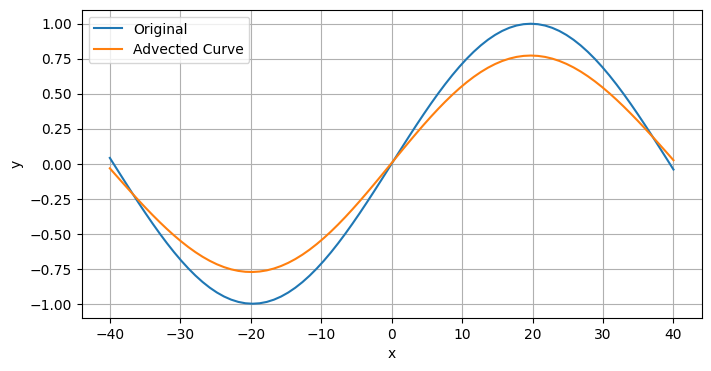

In [152]:
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y_base.numpy(), label='Original')
plt.plot(x.numpy(),C.numpy(), label='Advected Curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()



In [153]:
error = L_2_error(N, C, y_base)
print(error)

tensor(0.2221)


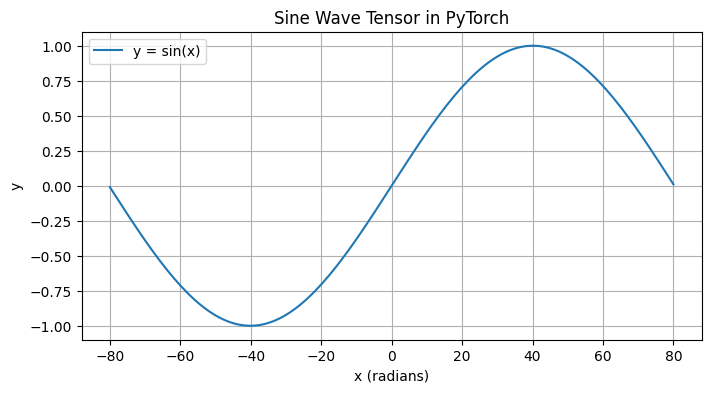

tensor([-80.0000, -78.9937, -77.9874, -76.9811, -75.9748, -74.9686, -73.9623,
        -72.9560, -71.9497, -70.9434, -69.9371, -68.9308, -67.9245, -66.9182,
        -65.9119, -64.9057, -63.8994, -62.8931, -61.8868, -60.8805, -59.8742,
        -58.8679, -57.8616, -56.8553, -55.8491, -54.8428, -53.8365, -52.8302,
        -51.8239, -50.8176, -49.8113, -48.8050, -47.7987, -46.7924, -45.7862,
        -44.7799, -43.7736, -42.7673, -41.7610, -40.7547, -39.7484, -38.7421,
        -37.7358, -36.7296, -35.7233, -34.7170, -33.7107, -32.7044, -31.6981,
        -30.6918, -29.6855, -28.6792, -27.6730, -26.6667, -25.6604, -24.6541,
        -23.6478, -22.6415, -21.6352, -20.6289, -19.6226, -18.6163, -17.6101,
        -16.6038, -15.5975, -14.5912, -13.5849, -12.5786, -11.5723, -10.5660,
         -9.5597,  -8.5535,  -7.5472,  -6.5409,  -5.5346,  -4.5283,  -3.5220,
         -2.5157,  -1.5094,  -0.5031,   0.5031,   1.5094,   2.5157,   3.5220,
          4.5283,   5.5346,   6.5409,   7.5472,   8.5535,   9.55

In [165]:
# We will now double the resolution in both space and time
dt = 0.025
N = 160
dx = 0.25
start_angle = -80
end_angle = 80
# Create the input tensor of angles (x-values)
x = torch.linspace(start_angle, end_angle, N)
y = torch.sin(0.123*x/math.pi)
C = y
y_base = y
plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y.numpy(), label='y = sin(x)')
plt.title('Sine Wave Tensor in PyTorch')
plt.xlabel('x (radians)')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()
print(x)

100%|██████████| 1600/1600 [00:00<00:00, 12166.46it/s]


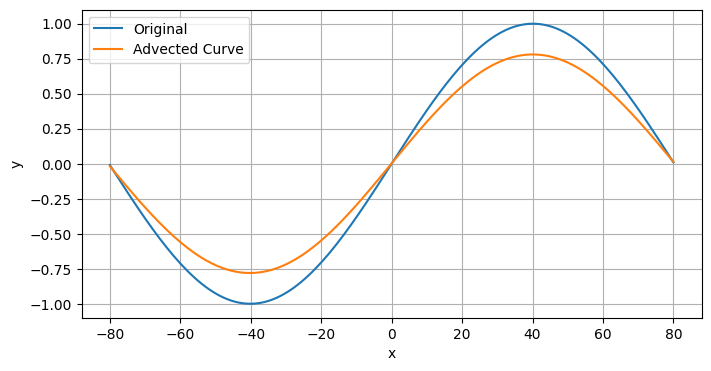

In [166]:
steps = 1600


# Reset C
C = y_base

for _ in tqdm(range(steps)):
    # trajectory.append(C.clone())  # store current state
    # times.append(t)
    
    C = rk4_advection(C, dt)

plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y_base.numpy(), label='Original')
plt.plot(x.numpy(),C.numpy(), label='Advected Curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()



In [144]:
error = L_2_error(N, C, y_base)
print(error)

tensor(0.1161)
